<a href="https://colab.research.google.com/github/myoungjinahn/Machine-Learning-project-team1/blob/main/Late_Autumn_afternoon_comfort_model_connection_%26_QA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
# Colab 및 로컬 실행용 공유 경로 설정

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass


Mounted at /content/drive


In [3]:
# CSV 파일 불러오기

search_dirs = [
    Path('/content/drive/MyDrive'),
    Path.cwd(),
    Path.home() / 'Downloads',
]

candidate_paths = []
for directory in search_dirs:
    if directory.exists():
        candidate_paths.extend(directory.glob('2013~2025*.csv'))

file_path = next((path for path in candidate_paths if 'Label' in pd.read_csv(path, encoding='utf-8-sig', nrows=0).columns), None)
if file_path is None:
    raise FileNotFoundError('Could not find the labeled CSV with columns including Label. Place it in MyDrive, cwd, or Downloads.')

raw_df = pd.read_csv(file_path, encoding='utf-8-sig')
print(f'Loaded: {file_path}')
print(f'Raw shape: {raw_df.shape}')
raw_df.head()


Loaded: /content/drive/MyDrive/2013~2025 가을 쾌적도 분류 라벨링 결과.csv
Raw shape: (1183, 4)


,Date_Key,PM25,Temp,Label
0,2013년09월_1일,13.1,28.2,0
1,2013년09월_2일,11.8,26.9,0
2,2013년09월_3일,9.7,26.8,0
3,2013년09월_4일,9.6,27.5,0
4,2013년09월_5일,11.1,24.1,0


In [4]:
# QA 1: 스키마/결측치 검사
required_cols = ['Date_Key', 'PM25', 'Temp', 'Label']
missing_cols = sorted(set(required_cols) - set(raw_df.columns))
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

df = raw_df[required_cols].copy()
df['PM25'] = pd.to_numeric(df['PM25'], errors='coerce')
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')
df['Label'] = pd.to_numeric(df['Label'], errors='coerce')

qa_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_rate': (df.isna().mean() * 100).round(2),
    'unique_count': df.nunique(dropna=True),
})
print('[QA] Column summary')
display(qa_summary)

invalid_label_rows = df[~df['Label'].isin([0, 1]) | df['Label'].isna()]
if not invalid_label_rows.empty:
    raise ValueError('Label must contain only 0/1 values. Check invalid_label_rows.')

before_rows = len(df)
df_model = df.dropna(subset=['PM25', 'Temp', 'Label']).copy()
df_model['Label'] = df_model['Label'].astype(int)
print(f'[QA] Missing-value cleanup: {before_rows} -> {len(df_model)} rows (removed {before_rows - len(df_model)})')


[QA] Column summary


,dtype,missing_count,missing_rate,unique_count
Date_Key,object,0,0.00,1183
PM25,float64,0,0.00,83
Temp,float64,1,0.08,295
Label,int64,0,0.00,2


[QA] Missing-value cleanup: 1183 -> 1182 rows (removed 1)


In [5]:
# QA 2: 라벨 규칙/중복 검사
# 쾌적함 (1): 14 <= 온도 <= 22 및 PM25 <= 35
rule_label = ((df_model['Temp'].between(14, 22, inclusive='both')) & (df_model['PM25'] <= 35)).astype(int)
label_mismatch = df_model.loc[rule_label != df_model['Label'], ['Date_Key', 'PM25', 'Temp', 'Label']].copy()
label_mismatch['Expected_Label'] = rule_label[rule_label != df_model['Label']].values

duplicate_count = df_model.duplicated(subset=['Date_Key']).sum()
class_counts = df_model['Label'].value_counts().sort_index()
class_rate = (df_model['Label'].value_counts(normalize=True).sort_index() * 100).round(2)

print(f'[QA] Duplicate Date_Key rows: {duplicate_count}')
print(f'[QA] Label-rule mismatches: {len(label_mismatch)}')
print('[QA] Class distribution')
display(pd.DataFrame({'count': class_counts, 'rate_%': class_rate}))

display(df_model[['PM25', 'Temp']].describe().T)

if duplicate_count > 0:
    raise ValueError('Duplicate Date_Key rows exist. Review duplicates before modeling.')
if not label_mismatch.empty:
    display(label_mismatch.head(20))
    raise ValueError('Some Label values do not match the project labeling rule.')


[QA] Duplicate Date_Key rows: 0
[QA] Label-rule mismatches: 0
[QA] Class distribution


,count,rate_%
Label,,
0,775,65.57
1,407,34.43


,count,mean,std,min,25%,50%,75%,max
PM25,1182.0,16.981303,11.006710,1.0,9.05,15.0,22.0,96.0
Temp,1182.0,20.303130,7.088872,-1.6,15.70,21.1,26.1,34.6


In [6]:
#  X, y 설정 (모델 연결)
feature_cols = ['Temp', 'PM25']
target_col = 'Label'

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Features: {feature_cols}, Target: {target_col}')


X shape: (1182, 2), y shape: (1182,)
Features: ['Temp', 'PM25'], Target: Label


In [7]:
# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('[Split] Train label rate')
display(y_train.value_counts(normalize=True).sort_index().rename('train_rate'))
print('[Split] Test label rate')
display(y_test.value_counts(normalize=True).sort_index().rename('test_rate'))


[Split] Train label rate


,train_rate
Label,
0,0.656085
1,0.343915


[Split] Test label rate


,test_rate
Label,
0,0.654008
1,0.345992


In [8]:
#  K값 탐색 (교차검증)
k_range = range(1, 21)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for k in k_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results.append({
        'k': k,
        'cv_mean_acc': scores.mean(),
        'cv_std_acc': scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results)
best_row = cv_results_df.sort_values(['cv_mean_acc', 'cv_std_acc', 'k'], ascending=[False, True, True]).iloc[0]
best_k = int(best_row['k'])

print('[CV] K search results')
display(cv_results_df.style.format({'cv_mean_acc': '{:.4f}', 'cv_std_acc': '{:.4f}'}))
print(f'Best K: {best_k} (CV mean accuracy={best_row.cv_mean_acc:.4f}, std={best_row.cv_std_acc:.4f})')


[CV] K search results


,k,cv_mean_acc,cv_std_acc
0,1,0.9810,0.0092
1,2,0.9841,0.0033
2,3,0.9799,0.0108
3,4,0.9820,0.0063
4,5,0.9778,0.0085
5,6,0.9831,0.0052
6,7,0.9788,0.0106
7,8,0.9852,0.0062
8,9,0.9820,0.0086
9,10,0.9862,0.0054


Best K: 10 (CV mean accuracy=0.9862, std=0.0054)


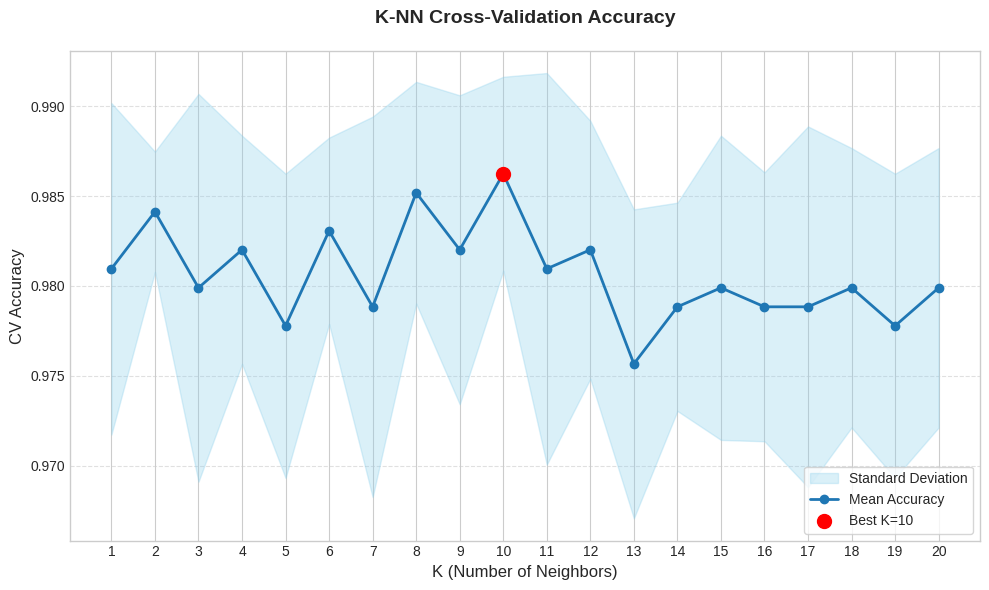

In [9]:
# 교차 검증 성능 시각화

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

plt.fill_between(
    cv_results_df['k'],
    cv_results_df['cv_mean_acc'] - cv_results_df['cv_std_acc'],
    cv_results_df['cv_mean_acc'] + cv_results_df['cv_std_acc'],
    color='skyblue', alpha=0.3, label='Standard Deviation'
)

plt.plot(
    cv_results_df['k'],
    cv_results_df['cv_mean_acc'],
    marker='o', markersize=6, color='#1f77b4', linewidth=2, label='Mean Accuracy'
)

plt.scatter(best_k, cv_results_df.loc[cv_results_df['k']==best_k, 'cv_mean_acc'],
            color='red', s=100, zorder=5, label=f'Best K={best_k}')

plt.title('K-NN Cross-Validation Accuracy', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('CV Accuracy', fontsize=12)
plt.xticks(cv_results_df['k'])
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

[Final performance]
Best K: 10
Train Accuracy: 0.9894
Test Accuracy : 0.9873
Train-Test Gap: 0.0021

[Classification report - Test Set]
                 precision    recall  f1-score   support

Not pleasant(0)       0.99      0.99      0.99       155
    Pleasant(1)       0.98      0.99      0.98        82

       accuracy                           0.99       237
      macro avg       0.98      0.99      0.99       237
   weighted avg       0.99      0.99      0.99       237



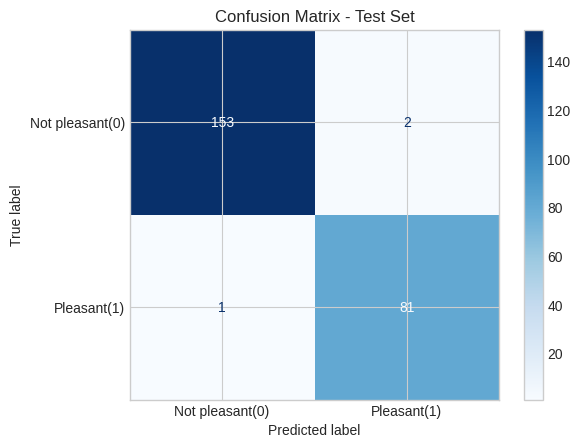

Diagnosis: Generalization looks stable: train/test gap is small and test performance is solid.


In [10]:
# 최종 모델 학습 및 평가
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])
best_model.fit(X_train, y_train)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_test_gap = abs(train_acc - test_acc)

print('[Final performance]')
print(f'Best K: {best_k}')
print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Train-Test Gap: {train_test_gap:.4f}')

print()
print('[Classification report - Test Set]')
print(classification_report(y_test, y_test_pred, target_names=['Not pleasant(0)', 'Pleasant(1)']))

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not pleasant(0)', 'Pleasant(1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.show()

if train_acc < 0.70:
    diagnosis = 'Possible underfitting: consider adding features or lowering K.'
elif (train_acc - test_acc) > 0.05:
    diagnosis = 'Possible overfitting: consider increasing K, rechecking CV, or adding more data.'
else:
    diagnosis = 'Generalization looks stable: train/test gap is small and test performance is solid.'

print(f'Diagnosis: {diagnosis}')


In [13]:
import pandas as pd

def predict_comfort_by_input():
    """
    사용자가 직접 입력한 기온과 미세먼지 수치를 바탕으로
    학습된 best_model을 통해 외출 적합 여부를 실시간으로 분류합니다.
    """
    print("=" * 45)
    print("      가을철 외출 쾌적도 분류 시스템")
    print("=" * 45)

    try:
        # 1. 사용자로부터 실시간 날씨 데이터 입력받기
        user_temp = float(input("현재 기온을 입력하세요 (°C): "))
        user_pm25 = float(input("현재 미세먼지(PM2.5) 농도를 입력하세요 (µg/m³): "))
    except ValueError:
        print("\n올바른 숫자만 입력해 주세요. (예: 18.5, 25)")
        print("=" * 45)
        return

    # 2. 모델 학습 시 적용된 피처 순서(['Temp', 'PM25'])와 동일하게 데이터프레임 생성
    input_data = pd.DataFrame([
        {
            'Temp': user_temp,  # 기온이 첫 번째 컬럼
            'PM25': user_pm25   # 미세먼지가 두 번째 컬럼
        }
    ])

    # 3. 기존에 학습 완료된 파이프라인 모델(best_model)로 결과 예측
    # (StandardScaler 스케일링과 KNN 분류가 파이프라인 내부에서 자동으로 처리됩니다)
    prediction = best_model.predict(input_data)[0]

    # 4. 분류 결과창 디자인 출력
    print("\n" + "=" * 45)
    print(f" [ 입력된 당일 날씨 정보 ]")
    print(f"  기온: {user_temp}°C")
    print(f"  미세먼지(PM2.5): {user_pm25} µg/m³")
    print("-" * 45)

    if prediction == 1:
        print(" AI 분류 결과: 오늘 외출은 [ 쾌적 ] 합니다!")
        print(" 산책이나 야외 활동을 즐기기에 아주 좋은 날씨입니다.")
    else:
        print(" AI 분류 결과: 오늘 외출은 [ 부적합 ] 합니다.")
        print(" 미세먼지 농도가 높거나 기온이 적절하지 않을 수 있으니 주의하세요.")
    print("=" * 45)

# --- 함수 실행 ---
# 셀을 실행하면 아래에 입력창이 순서대로 나타납니다.
predict_comfort_by_input()

      가을철 외출 쾌적도 분류 시스템
현재 기온을 입력하세요 (°C): 23
현재 미세먼지(PM2.5) 농도를 입력하세요 (µg/m³): 22.43

 [ 입력된 당일 날씨 정보 ]
  기온: 23.0°C
  미세먼지(PM2.5): 22.43 µg/m³
---------------------------------------------
 AI 분류 결과: 오늘 외출은 [ 부적합 ] 합니다.
 미세먼지 농도가 높거나 기온이 적절하지 않을 수 있으니 주의하세요.
